Используем датасет *Wine Quality Dataset* для изучения методов беггинга, бленинга и стекинга. Датасет небольшой и позволит изучить модели классификации. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import optuna


from matplotlib import pyplot as plt
from sklearn.model_selection import (cross_val_score, train_test_split,
                                     GridSearchCV, StratifiedKFold, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (VotingClassifier, RandomForestClassifier,
                            BaggingClassifier, StackingClassifier,
                            GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from typing import List, Tuple, Dict, Optional, Union





from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

/home/vvk/python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Описание признаков:
- Фиксированная кислотность (fixed acidity) - кислоты, содержащиеся в вине. Хорошая кислотная делает вино свежим и позволяет ему долго храниться.
- Лимонная кислота (citric acid) - часто добавлется в вино для подкисления.
- Летучая кислотность (volatile acidity) - кислоты, которые можно почуствовать запахом. **Важнейший показатель вина.** Высокое значение говорит о том, что вино было испорчено.
- Хлориды (chlorides) - соли, влиящие на вкус. Избыток хлоридов придаёт неприятный, горько-солёный вкус. 
- Плотность (density) - показвает соотношения сахара, спирта и воды. Высокая плотность говорит о том, что брожение пошло не так или вино чем-то загрязнено.
- Водородный показатель (pH) - мера активности кислоты. pH критически важен для стабильности. Низкая кислотность говорит о тусклости цвета вина, вино теряет вкус.
- Сульфаты (sulphates) - природные соли серной кислоты. В высоких концентрациях даёт горький вкус. В хороших винах сульфаты не должны ощущаться.
- Спирт (alcohol) - спирт придаёт винут "теплоту" и плотность. Чем выше градус, тем более насыщенным кажется вино. Спирт должен быть сбалансирован с кислотностью. 

Рассмотрим датасет:

In [2]:
df = pd.read_csv("WineQT.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


Датасет имеет 13 столбцов, столбец *Id* имеет уникальные значения, *quality* - качество вин, целевая переменная. Все признаки числовые.

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [5]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Text(0.5, 1.0, 'Распределение классов')

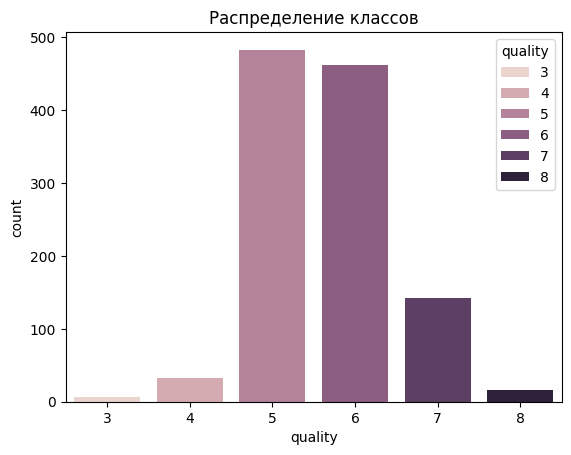

In [6]:
sns.countplot(data=df, x='quality', hue='quality')
plt.title('Распределение классов')

Оценка качества вина представлена в виде оценки от 0 до 10. В датасете есть 6 оценок, и некоторые из них малочисленные. То есть имеется дисбаланс классов.

Сократим число классов до 3-х. Классы 3 и 4 перейдут в 5 класс, а 8 класс в 7.

In [7]:
quality_mapping = {
    3: 5,
    4: 5,
    8: 7
}
df['quality'] = df['quality'].replace(quality_mapping)

In [8]:
df['quality'].value_counts().sort_index()

quality
5    522
6    462
7    159
Name: count, dtype: int64

In [9]:
print(df.shape)

(1143, 13)


In [10]:
columns = df.columns
columns = columns[0:-2]
X = df[columns]
y = df['quality']

Дисбаланс классов остался, но уже не такой значительный.

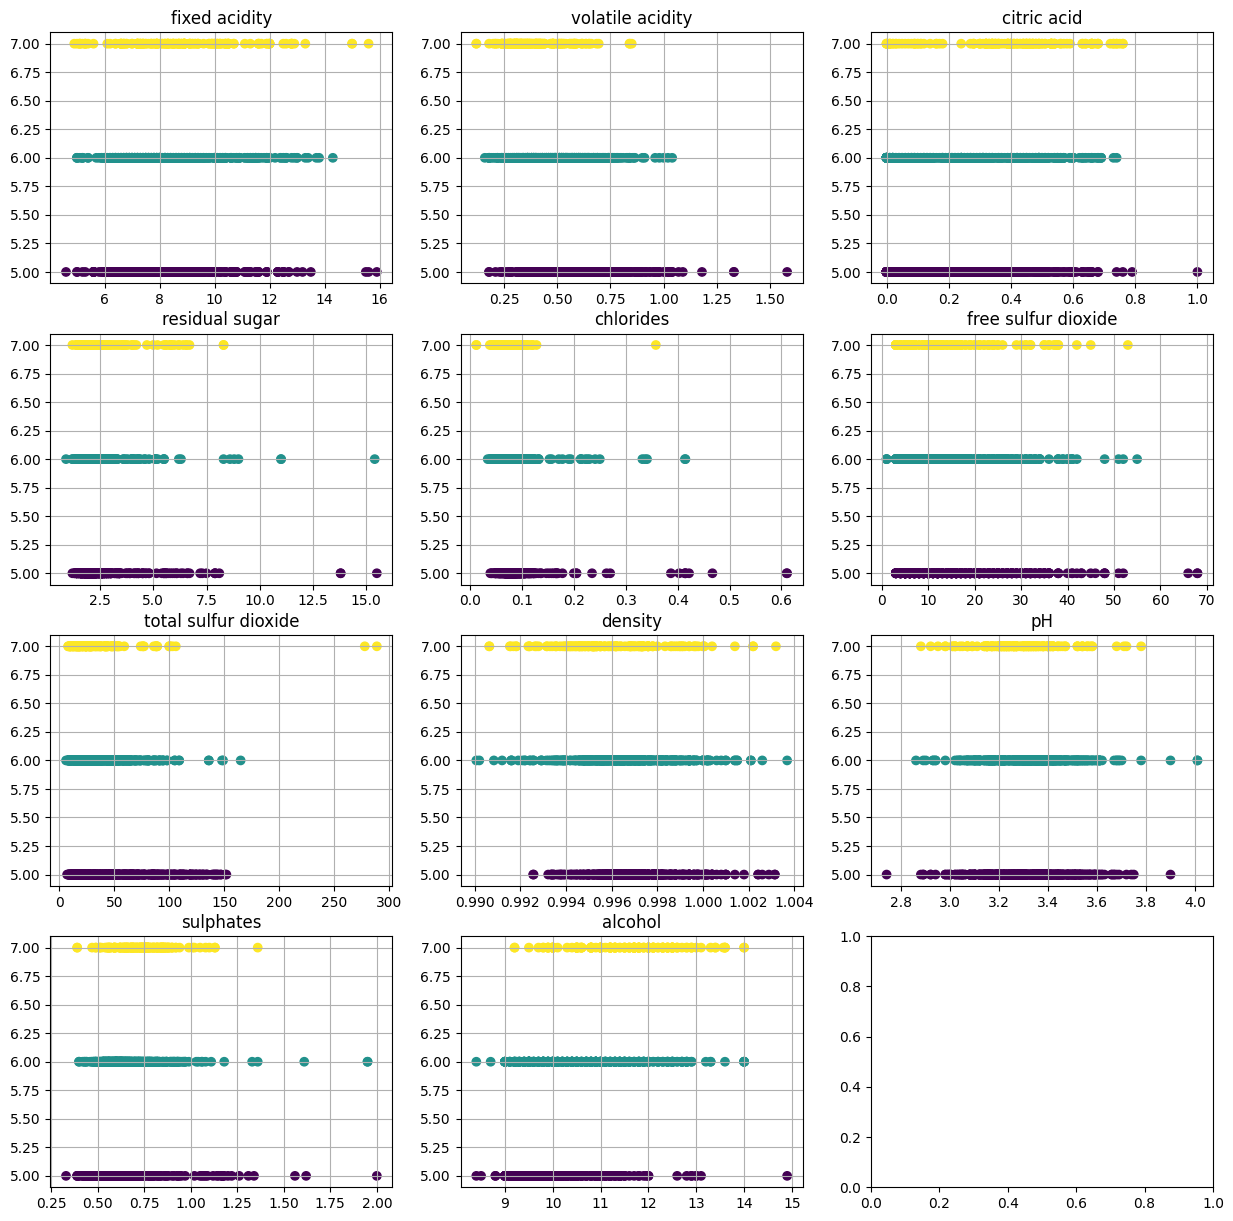

In [11]:
fg, ax = plt.subplots(4, 3, figsize=(15, 15))
ax = ax.flatten()
for idx, col in enumerate(columns):
    ax[idx].scatter(x=df[col], y=df['quality'], c=y)
    ax[idx].set_title(col)
    ax[idx].grid()

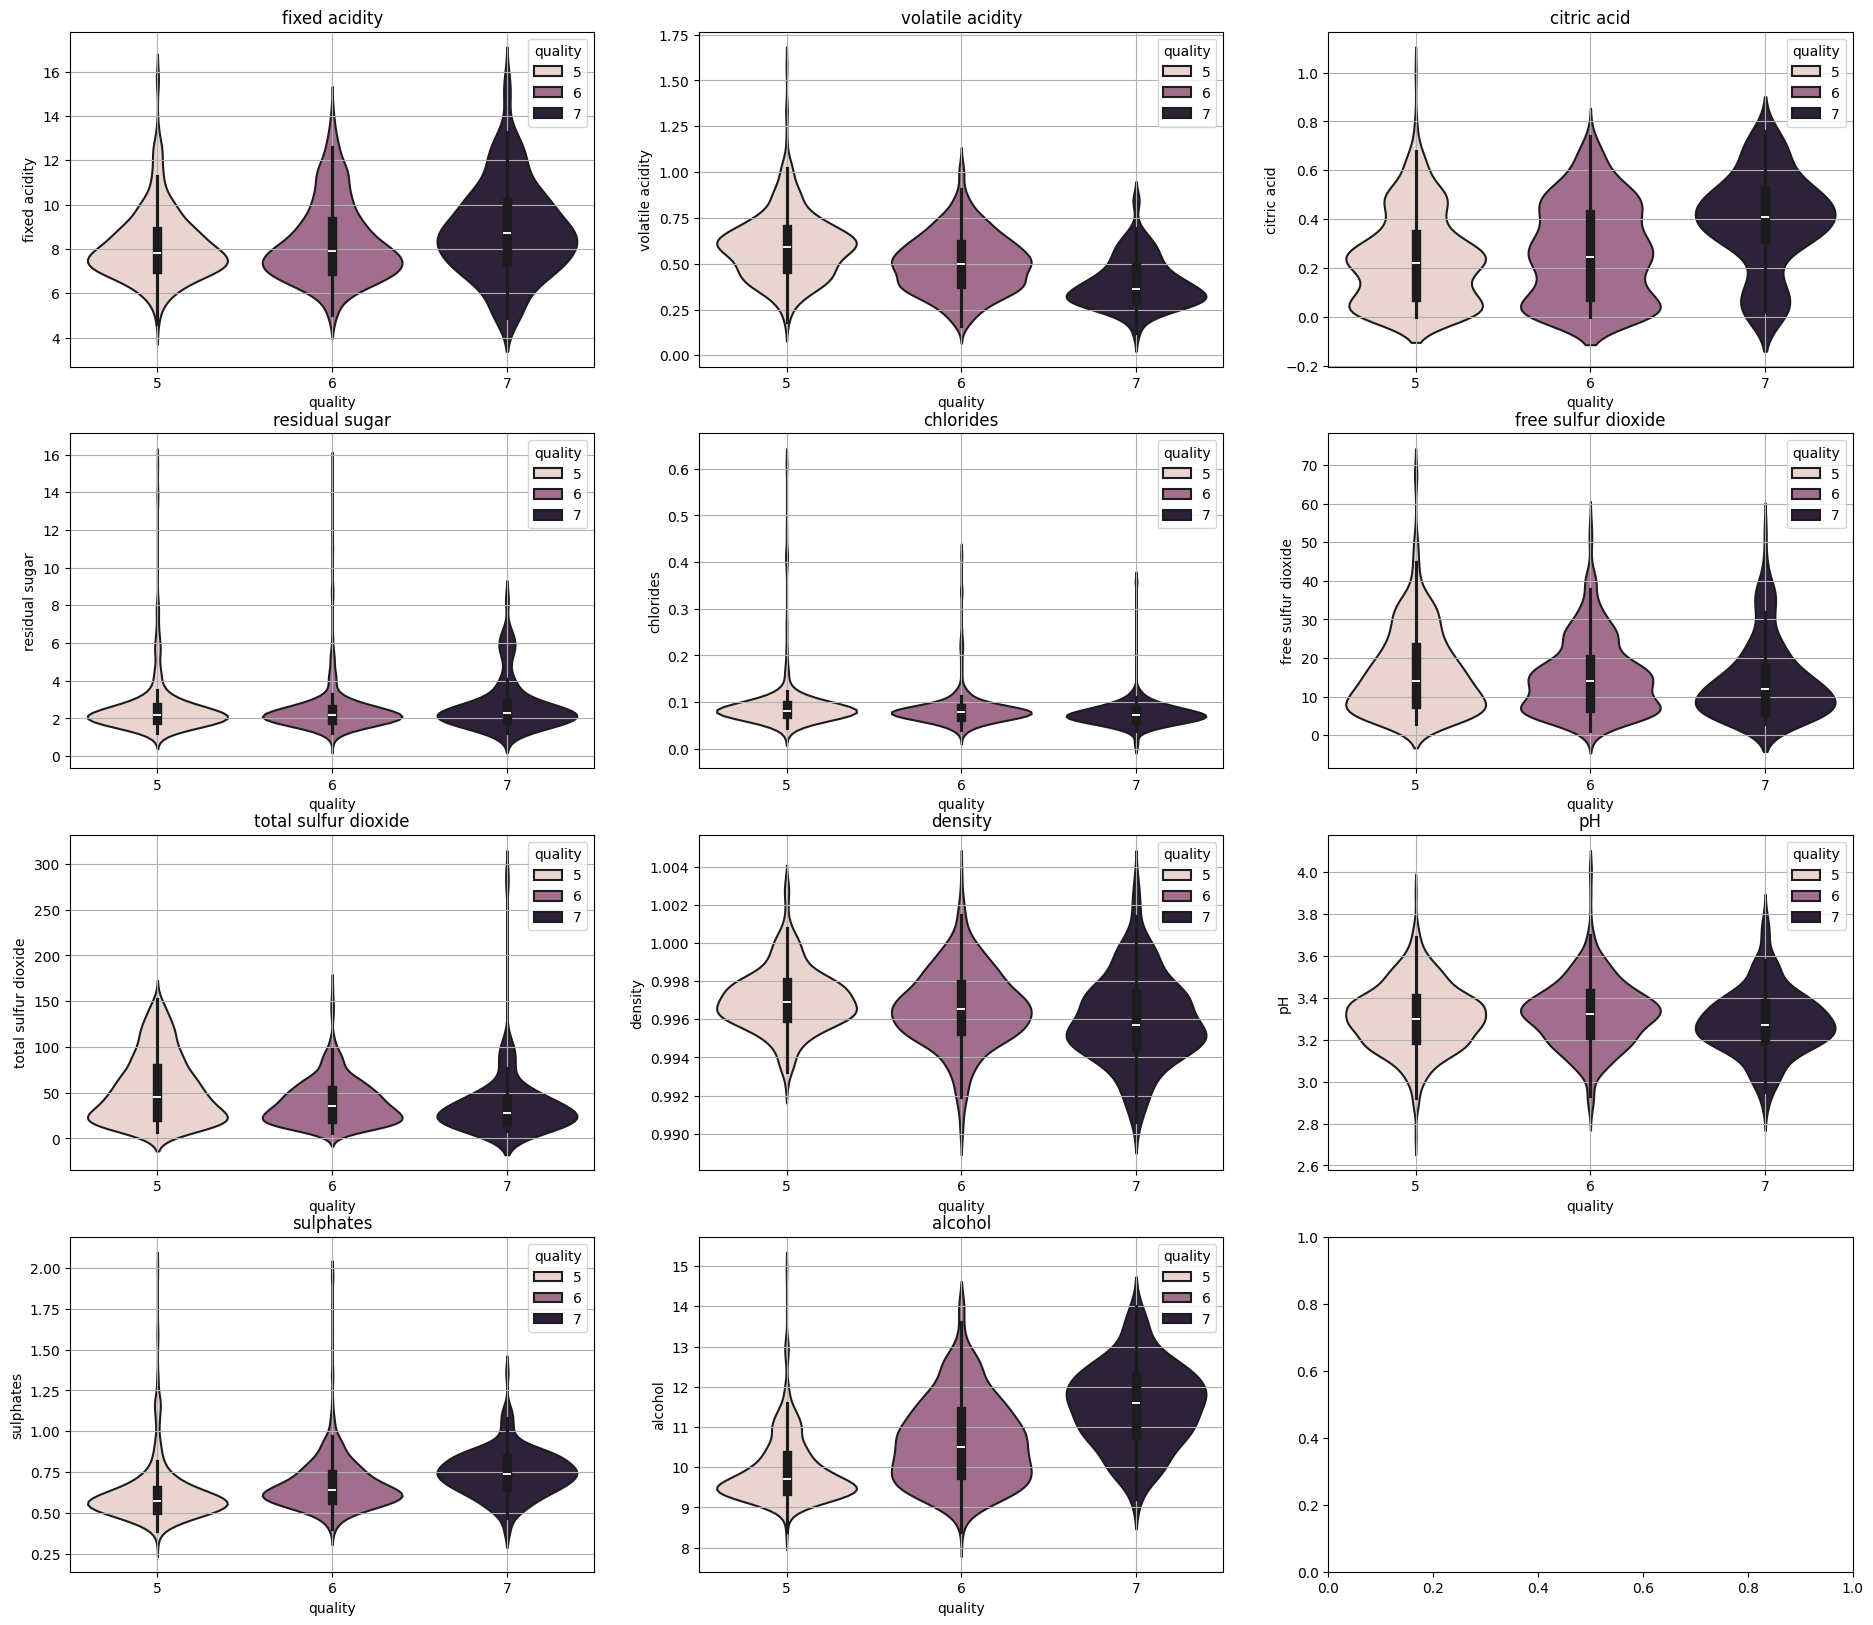

In [12]:
fg, ax = plt.subplots(4, 3, figsize=(23, 20))
ax = ax.flatten()
for idx, col in enumerate(columns):
    sns.violinplot(
        data=df,
        x='quality',
        y=col,
        ax=ax[idx],
        hue='quality',
        linewidth=1.5
    )
    ax[idx].set_title(col)
    ax[idx].grid()

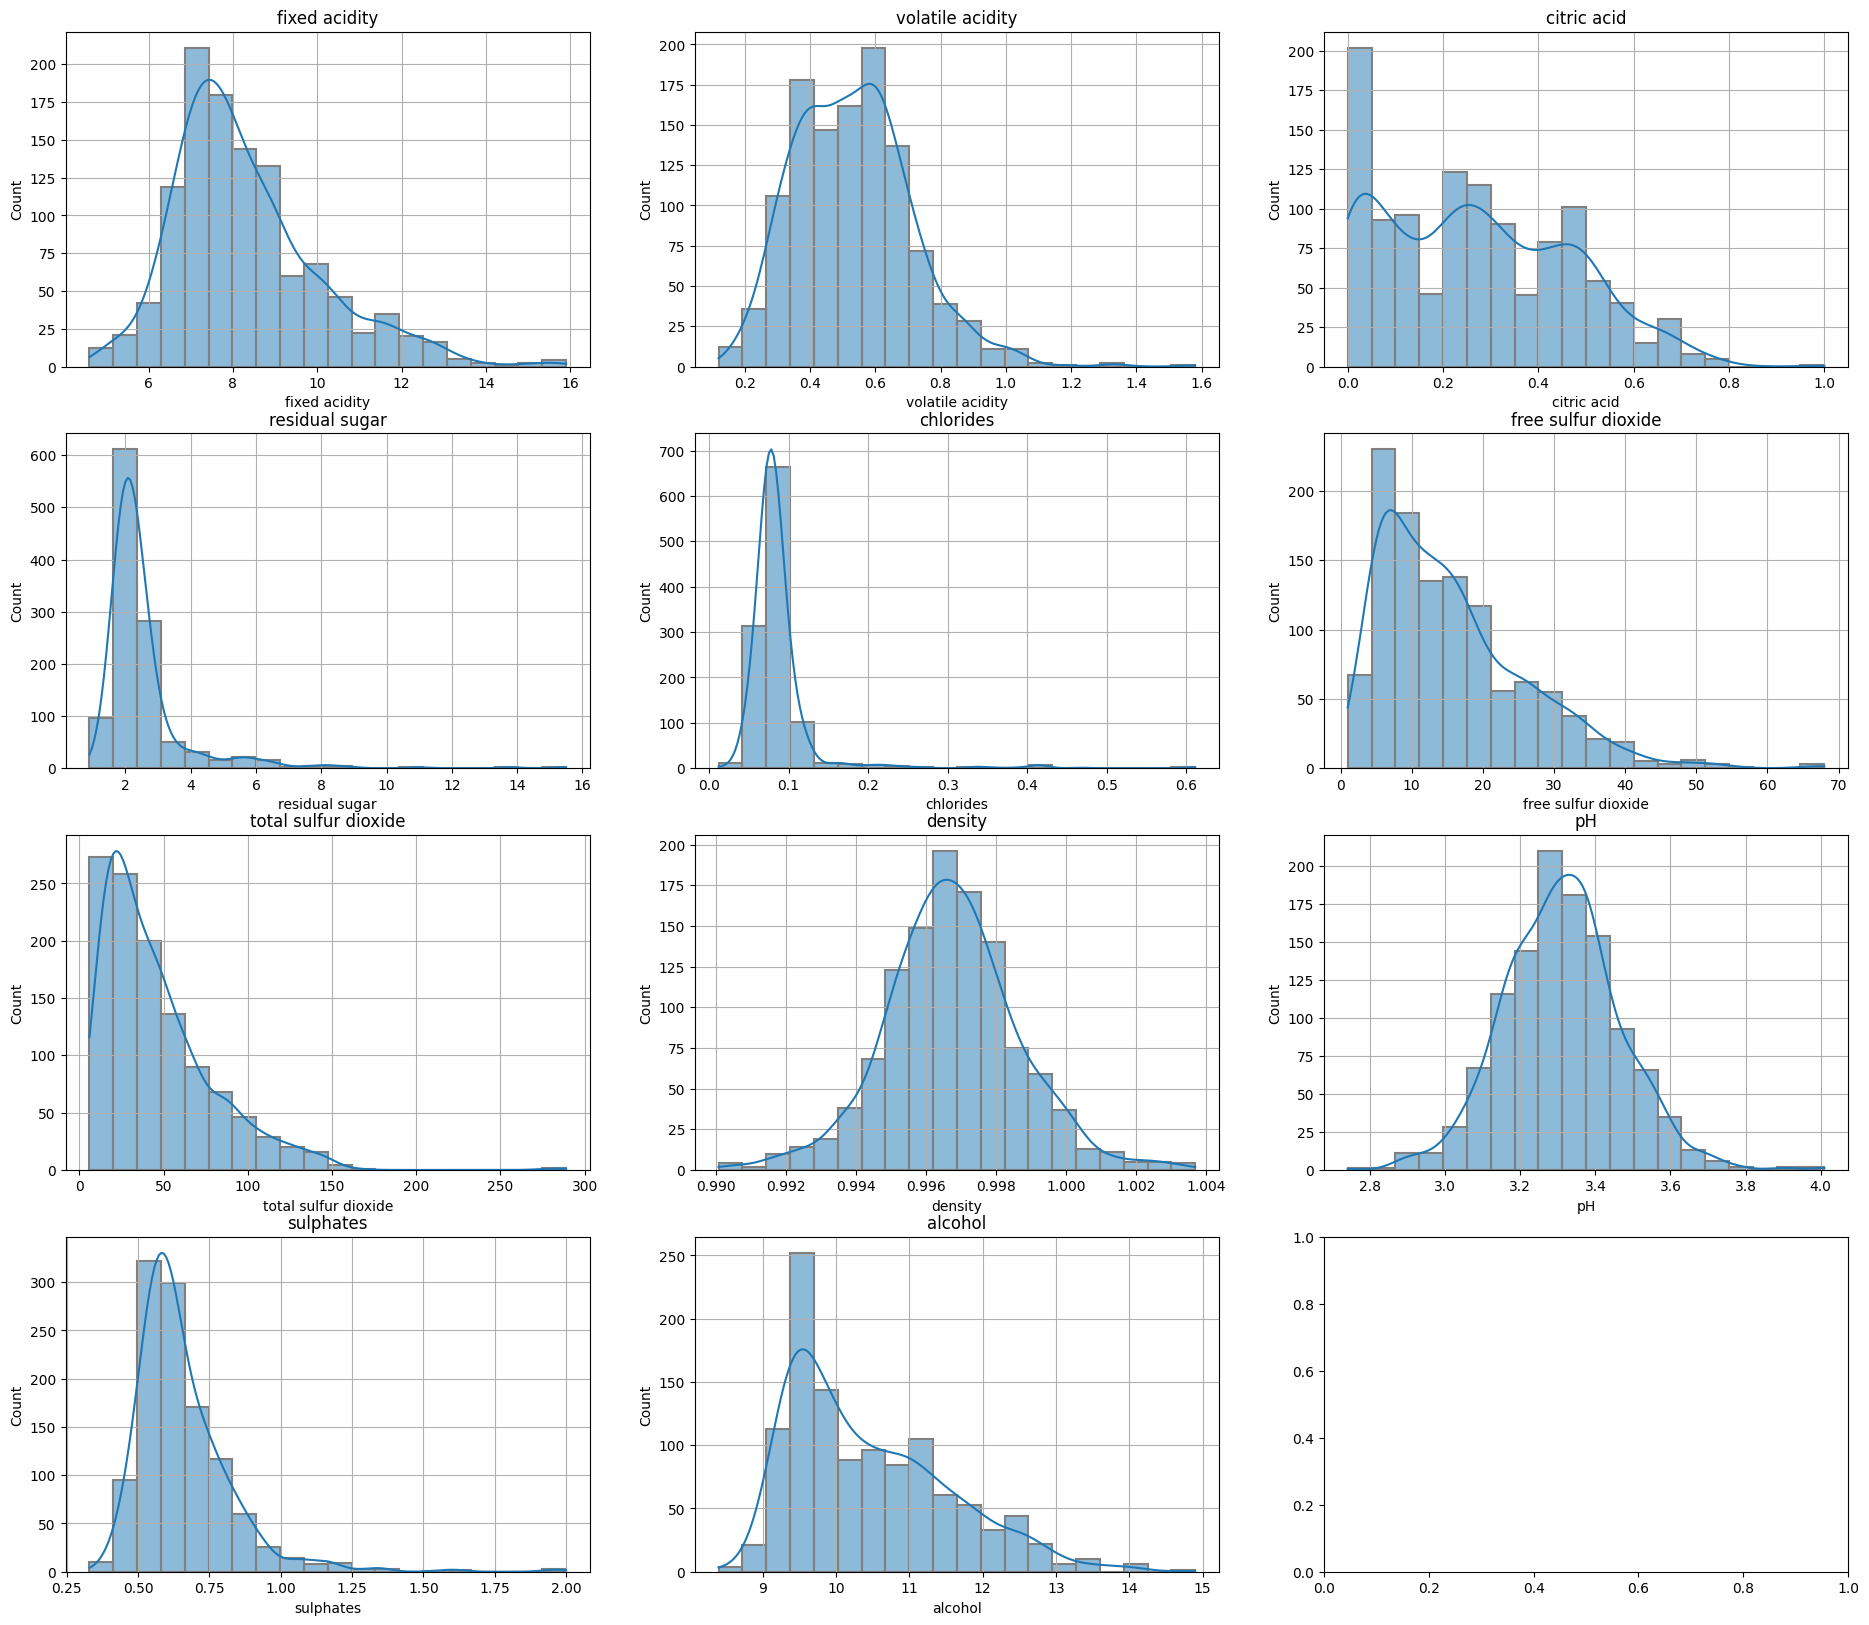

In [13]:
fg, ax = plt.subplots(4, 3, figsize=(23, 20))
ax = ax.flatten()
for idx, col in enumerate(columns):
    sns.histplot(
        data=df[col],
        ax=ax[idx],
        linewidth=1.5,
        bins=20,
        kde=True,
        edgecolor='gray'
    )
    ax[idx].set_title(col)
    ax[idx].grid()


Есть переменные, которые имеют правосторонние хвосты и скошенность. Измерим параметр skew для всех признаков.

In [14]:
skew_vals = df[columns].skew().sort_values(ascending=False)
print('Ассиметрия всех признаков:')
print(skew_vals)

Ассиметрия всех признаков:
chlorides               6.026360
residual sugar          4.361096
sulphates               2.497266
total sulfur dioxide    1.665766
free sulfur dioxide     1.231261
fixed acidity           1.044930
alcohol                 0.863313
volatile acidity        0.681547
citric acid             0.371561
pH                      0.221138
density                 0.102395
dtype: float64


# EDA

Применим логарифмическое преобразование к признакам, которые имеют сильную ассиметрию. Это позволит уменьшить скошенность, уменьшает длинный хвост, делает данные более нормальным. Также для признаков Хлориды, Сахар и Сульфаты применим клиппинг для устранения выбросов. Для остальных признаков применим масштабирование к виду стандартного нормального распределения. 

In [15]:
skew_vals_col = skew_vals[skew_vals > 1.1].index.to_list()
norm_vals_col = [col for col in columns if col not in skew_vals_col]
robust_skewes = skew_vals[skew_vals > 2].index.to_list()
normal_skewes = [col for col in skew_vals_col if col not in robust_skewes]
print('Признаки с сильной ассиметрией и выбросами:')
print(robust_skewes)
print()
print('Признаки с сильной ассиметрией:')
print(normal_skewes)
print()
print('Остальные признаки:')
print(norm_vals_col)

Признаки с сильной ассиметрией и выбросами:
['chlorides', 'residual sugar', 'sulphates']

Признаки с сильной ассиметрией:
['total sulfur dioxide', 'free sulfur dioxide']

Остальные признаки:
['fixed acidity', 'volatile acidity', 'citric acid', 'density', 'pH', 'alcohol']


Создание пайплайнов для препроцессора:

In [16]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_features: List[str], iqr_multiplier: float = 1.5) -> None:
            """
            Инициализация класса
            """
            self.numeric_features = numeric_features
            self.iqr_multiplier = iqr_multiplier
            self.clipping_bounds_: Dict[str, Tuple[float, float]] = {}

    def fit(self, X: Union[np.ndarray, pd.DataFrame], y: Optional[np.ndarray] = None) -> 'OutlierClipper':
        """
        Вычисляет границы clip для каждого признака на основе IQR.
        """
        X_df = X[self.numeric_features]   
        for col in self.numeric_features:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - self.iqr_multiplier * IQR
            upper_bound = Q1 + self.iqr_multiplier * IQR
            self.clipping_bounds_[col] = (lower_bound, upper_bound)

        return self

    def transform(self, X: Union[np.ndarray, pd.DataFrame]) -> Union[np.ndarray, pd.DataFrame]:
        X_df = X[self.numeric_features]
        for col, (lower_bound, upper_bound) in self.clipping_bounds_.items():
            X_df[col] = np.clip(X_df[col], lower_bound, upper_bound)

        return X_df
    
    def get_feature_names_out(self, input_features=None) -> List[str]:
        """
        Возвращает имена признаков после преобразования.
        """
        if input_features is None:
            return self.numeric_features
        return input_features

In [17]:
preprocessor = ColumnTransformer([
    ('normal', Pipeline([
        ('scale', StandardScaler())
    ]), norm_vals_col),
    ('skewed', Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scale', StandardScaler()),
    ]), normal_skewes),
    ('skewed_robust', Pipeline([
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('clip', OutlierClipper(robust_skewes, iqr_multiplier=3.5)),
        ('scale', StandardScaler()),
    ]), robust_skewes),
],
remainder="drop",
verbose_feature_names_out=False
)

Применим препроцессора на данные и посмотрим изменения на графиках распределения:

In [18]:
X = df[columns]
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [19]:
preprocessor.fit(X_train)

X_train_pr = preprocessor.transform(X_train)
X_test_pr = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(X_train_pr, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_pr, columns=feature_names, index=X_test.index)


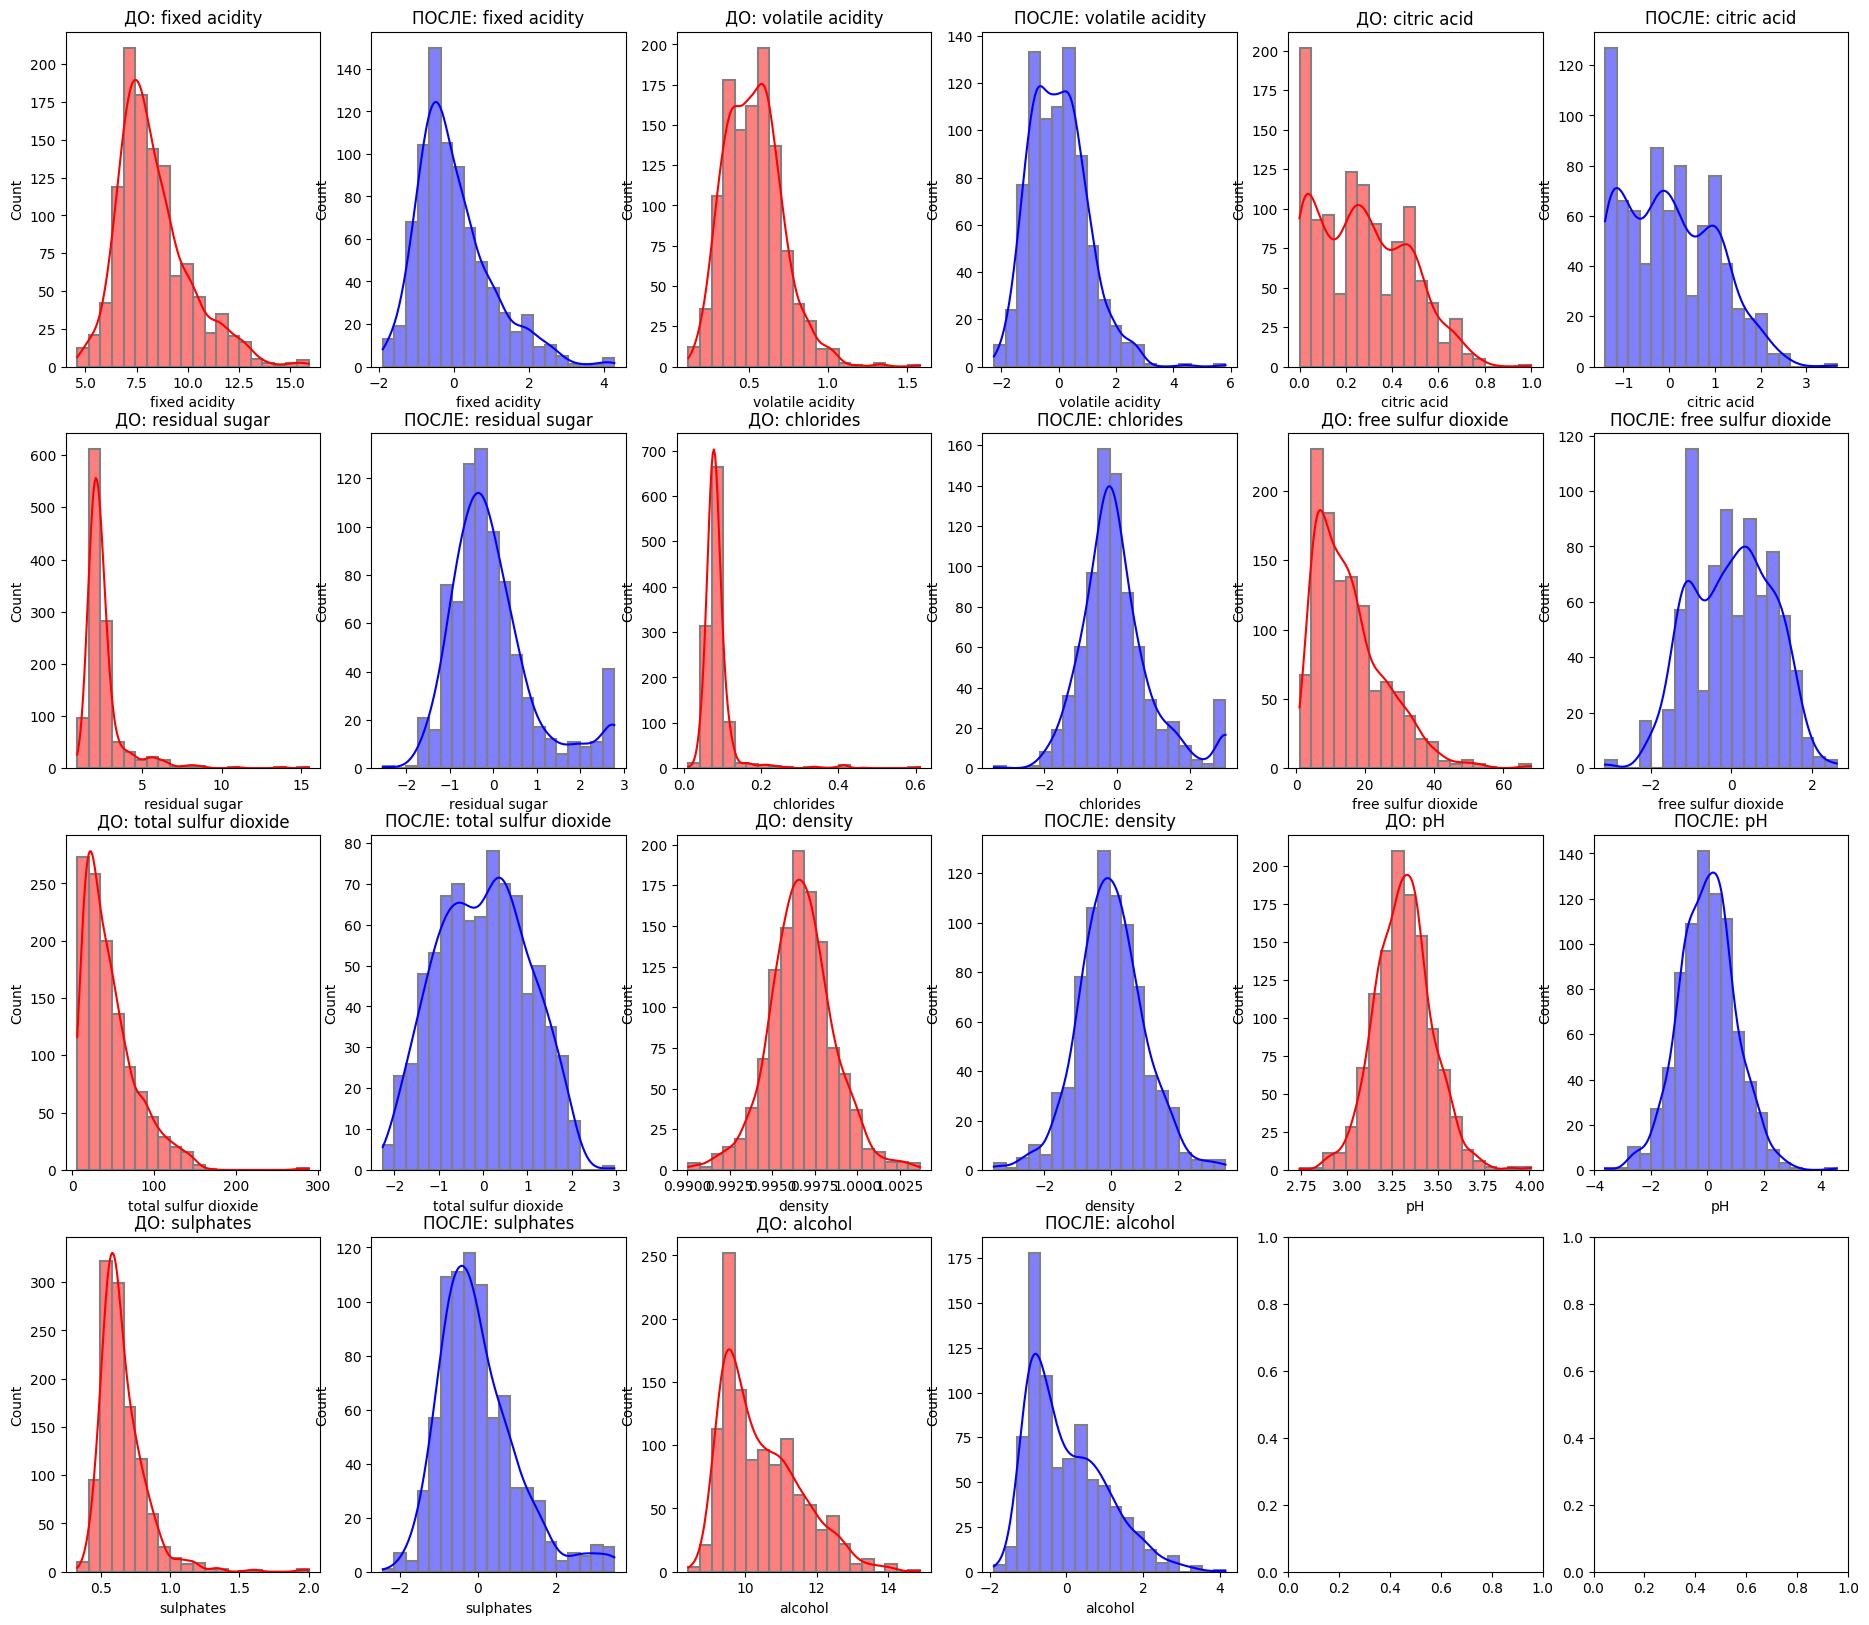

In [20]:
fg, ax = plt.subplots(4, 3*2, figsize=(23, 20))
ax = ax.flatten()
for idx, col in enumerate(columns):
    sns.histplot(
        data=df[col],
        ax=ax[idx*2],
        linewidth=1.5,
        bins=20,
        kde=True,
        color='red',
        edgecolor='gray'
    )
    ax[idx*2].set_title(f'ДО: {col}')

    sns.histplot(
        data=X_train_processed_df[col],
        ax=ax[idx*2+1],
        linewidth=1.5,
        bins=20,
        kde=True,
        color='blue',
        edgecolor='gray'
    )
    ax[idx*2+1].set_title(f'ПОСЛЕ: {col}')

In [21]:
skew_vals = X_train_processed_df[columns].skew().sort_values(ascending=False)
print('Ассиметрия преобразованных признаков:')
print(skew_vals)

Ассиметрия преобразованных признаков:
residual sugar          1.237857
fixed acidity           1.100576
sulphates               1.076672
chlorides               1.045818
alcohol                 0.864421
volatile acidity        0.725657
citric acid             0.359207
density                 0.113509
pH                      0.076936
total sulfur dioxide    0.020789
free sulfur dioxide    -0.096554
dtype: float64


В качестве метрики возьмём *f1_weighted*, которая учитывает вес каждого класса. Эта метрика подходит, так как в датасете имеется дисбаланс классов. 

## 1 Baseline-модель (Classification)

In [22]:
X = df[columns]
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print('Обучающая выборка: ', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка:  (800, 11)
Тестовая выборка:  (343, 11)


In [23]:
lr_model = Pipeline([
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(random_state=42, n_jobs=-1))
])

lr_param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['saga'],
    'logreg__max_iter': [100, 500, 1000]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = GridSearchCV(
    lr_model,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1_weighted',
    verbose=0,
    n_jobs=-1)

lr_cv.fit(X_train, y_train)
print('Baseline (Classification):')
print('Лучшие параметры:', lr_cv.best_params_)
print('Лучшая метрика f1_weighted:', lr_cv.best_score_)

Baseline (Classification):
Лучшие параметры: {'logreg__C': 1, 'logreg__max_iter': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'saga'}
Лучшая метрика f1_weighted: 0.6353137608098802


# 2 Decision Tree

In [24]:
decision_tree = Pipeline([
    ("dectree", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'dectree__max_depth': [3, 5, 7, None],
    'dectree__min_samples_split': [2, 5, 10, 15],
    'dectree__min_samples_leaf': [5, 10, 15, 20],
    'dectree__criterion': ['gini', 'entropy'],
    'dectree__class_weight': [None, 'balanced']
}

dt_cv= GridSearchCV(
    decision_tree,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1_weighted",
    verbose=0,
    n_jobs=-1
)

dt_cv.fit(X_train, y_train)
print('Decision Tree:')
print('Лучшие параметры:', dt_cv.best_params_)
print('Лучшая метрика f1_weighted:', dt_cv.best_score_)

Decision Tree:
Лучшие параметры: {'dectree__class_weight': None, 'dectree__criterion': 'gini', 'dectree__max_depth': 7, 'dectree__min_samples_leaf': 10, 'dectree__min_samples_split': 2}
Лучшая метрика f1_weighted: 0.6449930024861658


Дерево решений немного выигрывает у baseline-модели.

# 3 SVC

In [25]:
svc_model = Pipeline([
    ("preprocess", preprocessor),
    ("svc", SVC(random_state=42))
])

svc_param_grid = {
    'svc__C': [0.01, 1, 10, 100, 1000],
    'svc__kernel': ['linear', 'rbf'],
    'svc__class_weight': [None, 'balanced']
}

svc_cv= GridSearchCV(
    svc_model,
    param_grid=svc_param_grid,
    cv=cv,
    scoring="f1_weighted",
    verbose=0,
    n_jobs=-1
)

svc_cv.fit(X_train, y_train)
print('SVC:')
print('Лучшие параметры:', svc_cv.best_params_)
print('Лучшая метрика f1_weighted:', svc_cv.best_score_)

SVC:
Лучшие параметры: {'svc__C': 1000, 'svc__class_weight': None, 'svc__kernel': 'linear'}
Лучшая метрика f1_weighted: 0.6383598811985054


# 4 KNN

In [26]:
knn_model = Pipeline([
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 9, 15, 20],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

knn_cv= GridSearchCV(
    knn_model,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1_weighted",
    verbose=0,
    n_jobs=-1
)

knn_cv.fit(X_train, y_train)
print('KNN:')
print('Лучшие параметры:', knn_cv.best_params_)
print('Лучшая метрика f1_weighted:', knn_cv.best_score_)


KNN:
Лучшие параметры: {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}
Лучшая метрика f1_weighted: 0.6528980641638557


# 5 Random Forest

Создание функции для подбора гиперпараметров через *optuna* и её запуска

In [27]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, verbose=0)

def objective(trial):
        param_optuna = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 300),
        'max_depth': trial.suggest_int('max_depth', 1, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
        }
        
        random_forest_pipeline = rf_model
        random_forest_pipeline.set_params(**param_optuna)

        scores = cross_val_score(
                    random_forest_pipeline,
                    X_train, y_train, 
                    cv=cv, 
                    scoring='f1_weighted',
                    n_jobs=-1
                )
        return np.mean(scores)

def run_optuna_cv(n_trials):
        study = optuna.create_study(
            direction='maximize'
        )
        study.optimize(
            objective,
            n_trials=n_trials,
            n_jobs=-1,
            show_progress_bar=False,
        )

        return study

n_trials = 100
study = run_optuna_cv(n_trials)
best_params = study.best_params
best_score = study.best_value

best_rf = RandomForestClassifier(**best_params, random_state=42)

print('Random Forest:')
print(f"Лучшее значение f1_weighted: {best_score}")
print("Лучшие параметры:")
for key, value in best_params.items():
    print(f"{key}: {value}")

[I 2026-03-22 20:11:38,333] A new study created in memory with name: no-name-40ca8429-e226-4e4c-85b9-bfc483c891e6


[I 2026-03-22 20:11:40,314] Trial 3 finished with value: 0.6337678910234494 and parameters: {'n_estimators': 155, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None, 'criterion': 'log_loss'}. Best is trial 3 with value: 0.6337678910234494.
[I 2026-03-22 20:11:41,557] Trial 1 finished with value: 0.6337678910234494 and parameters: {'n_estimators': 275, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None, 'bootstrap': True, 'class_weight': None, 'criterion': 'entropy'}. Best is trial 3 with value: 0.6337678910234494.
[I 2026-03-22 20:11:41,775] Trial 0 finished with value: 0.6337678910234494 and parameters: {'n_estimators': 151, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True, 'class_weight': None, 'criterion': 'entropy'}. Best is trial 3 with value: 0.6337678910234494.
[I 2026-03-22 20:11:43,195] Trial 4 finished with v

Random Forest:
Лучшее значение f1_weighted: 0.6834763159531064
Лучшие параметры:
n_estimators: 217
max_depth: 15
min_samples_split: 12
min_samples_leaf: 2
max_features: sqrt
bootstrap: True
class_weight: None
criterion: log_loss


Лучший результат *f1_weighted* среди всех моделей.

Объединим несколько слабых моделей с помощью классификатора на основе голосования, блэндинга и стэкинга.

# 6 Voting Classifier

In [28]:
clf1 = Pipeline([
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(C = 1,
                          max_iter = 100,
                          penalty = 'l2',
                          solver = 'saga',
                          random_state=42,
                          n_jobs=-1))
])

clf2 = Pipeline([
    ("dectree", DecisionTreeClassifier(class_weight = None,
                              criterion = 'gini',
                              max_depth = 7, 
                              min_samples_leaf = 10, 
                              min_samples_split = 2,
                              random_state=42))
])

clf3 = Pipeline([
    ("preprocess", preprocessor),
    ("svc", SVC(C = 1000,
           class_weight = None,
           kernel = 'linear',
           random_state=42
           ))
])

clf4 = Pipeline([
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors = 9,
                            p = 1,
                            weights = 'distance'))
])

clf5 = Pipeline([
    ("ranforest", RandomForestClassifier(n_estimators = 99,
                                        max_depth = 13,
                                        min_samples_split = 4,
                                        min_samples_leaf = 2,
                                        max_features = 'sqrt',
                                        bootstrap = True,
                                        class_weight = 'balanced',
                                        criterion = 'entropy',
                                        random_state=42,
                                        n_jobs=-1, 
                                        verbose=0))
])

In [29]:
estimators = [('lr', clf1),
              ('dt', clf2),
              ('svc', clf3),
              ('knn', clf4)]
#hard voting
ensebmle_clf_hard = VotingClassifier(estimators=estimators, voting='hard',
                                     weights=[0.1, 0.1, 0.1, 0.7])

vot_score_hard = cross_val_score(ensebmle_clf_hard,
                                 X_train,
                                 y_train,
                                 scoring='f1_weighted',
                                 cv=cv)
print(vot_score_hard.mean())

0.6528980641638557


VotingClassifier не смог улучшить предсказания слабых моделей.

# 7 Bagging

In [30]:
n = 50 #число деервьев

decision_tree = DecisionTreeClassifier(random_state=42)
ensebmle_bagging = BaggingClassifier(estimator=decision_tree,
                                     n_estimators = n,
                                     max_samples=0.8,
                                     oob_score=True,
                                     random_state=42,
                                     n_jobs=-1)
bag_param_grid = {
    'estimator__max_depth': [3, 5, 7, None],
    'estimator__min_samples_split': [2, 5, 10, 15],
    'estimator__min_samples_leaf': [5, 10, 15, 20],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__class_weight': [None, 'balanced']
}

bag_cv= GridSearchCV(
    ensebmle_bagging,
    param_grid=bag_param_grid,
    cv=cv,
    scoring="f1_weighted",
    verbose=0,
    n_jobs=-1
)

bag_cv.fit(X_train, y_train)
print('Bagging:')
print('Лучшие параметры:', bag_cv.best_params_)
print('Лучшая метрика f1_weighted:', bag_cv.best_score_)

Bagging:
Лучшие параметры: {'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': None, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 2}
Лучшая метрика f1_weighted: 0.6671884839583699


Бэггинг выдал метрику чуть больше, чем единичное дерево, но хуже, чем случайный лес.

# 8 Stacking

In [37]:
estimators = [('lr', clf1),
              ('dt', clf2),
              ('svc', clf3),
              ('knn', clf4)]

ensebmle_stacking = StackingClassifier(estimators=estimators,
                        final_estimator=LogisticRegression())

stack_score = cross_val_score(ensebmle_stacking,
                              X_train,
                              y_train,
                              scoring='f1_weighted',
                              cv=cv)
stack_score = stack_score.mean()

In [ ]:
print(stack_score)

0.6783752473949178


Stacking смог заметно улучшить метрики слабых моделей.

Напоследок используем самую базовую модель бустинга.

# 9 Boosting

In [33]:
g_boost = GradientBoostingClassifier(random_state=42)

boost_param_grid = {'loss': ['log_loss', 'exponential'],
                    'learning_rate': [0.01, 0.5, 0.1, 0.2],
                    'n_estimators': [100, 200, 300],
                    'max_depth': [2, 3, 4, 5, 6],
                    'min_samples_split': [2, 5, 10],
                    'subsample': [1],
                    'max_features': ['sqrt', 'log2'],
                    'criterion': ['friedman_mse', 'squared_error']
                    }

gb_rs = RandomizedSearchCV(
    estimator=g_boost,
    param_distributions=boost_param_grid,
    n_iter=100, 
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

gb_rs.fit(X_train, y_train)
print('Boosting:')
print('Лучшие параметры:', gb_rs.best_params_)
print('Лучшая метрика f1_weighted:', gb_rs.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Boosting:
Лучшие параметры: {'subsample': 1, 'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.1, 'criterion': 'friedman_mse'}
Лучшая метрика f1_weighted: 0.6801829180546733


Использовался случайный подбор параметров, уудалось достичь метрики близкой к случайному лесу

# Проверка на тесте

In [46]:
rf_pipeline = best_rf
stack_pipeline = ensebmle_stacking
boost_pipeline = g_boost
boost_pipeline.set_params(**gb_rs.best_params_)

best_pipelines = [rf_pipeline, stack_pipeline, boost_pipeline]
name_pipelines = ['Random Forest', 'Stacking', 'Boosting']
train_score = [best_score, stack_score, gb_rs.best_score_]
table_out = {}
for idx, model in enumerate(best_pipelines):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_score = f1_score(y_test, y_pred, average='weighted')
    table_out[name_pipelines[idx]] = [train_score[idx], test_score]


In [88]:
res_df = pd.DataFrame(data=table_out, index=['Train', 'Test'])
res_df

,Random Forest,Stacking,Boosting
Train,0.683476,0.678375,0.680183
Test,0.666915,0.702222,0.659418


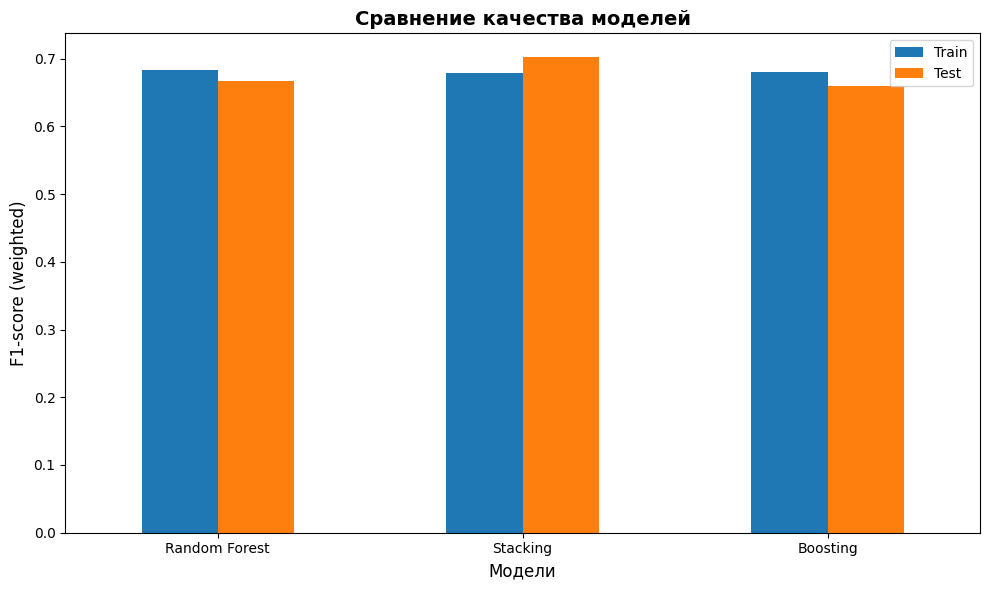

In [89]:
res_df = res_df.T
# res_df_plot.reset_index(names='Model', inplace=True)
res_df[['Train', 'Test']].plot(kind='bar', figsize=(10, 6))

plt.title('Сравнение качества моделей', fontsize=14, fontweight='bold')
plt.xlabel('Модели', fontsize=12)
plt.ylabel('F1-score (weighted)', fontsize=12)
plt.xticks(rotation=0)

# for container in plt.gca().containers:
#     plt.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

# Выводы

1. Были изучены и построены базовые модели классификации, такие как:
    - Модель логистической регрессии
    - Дерево решений
    - Метод опорных векторов
    - Модель k-ближайших соседей

2. Были построены ансамблевые модели:
    - Случайный лес
    - Классификатор голосования
    - Бэггинг
    - Стэкинг
    - Бустинг

| Метод | Описание |
|:------|:---------|
| **Случайный лес** (*Random Forest*) | Ансамбль деревьев решений |
| **Классификатор голосования** (*Voting Classifier*) | Агрегация предсказаний нескольких моделей |
| **Бэггинг** (*Bagging*) | Параллельное обучение моделей на разных подвыборках, формируемых с помощью bootstrap |
| **Стэкинг** (*Stacking*) | Многоуровневый ансамбль с мета-моделью, которая строится на предсказаниях |
| **Бустинг** (*Boosting*) | Последовательное исправление ошибок моделей |

3. Для некоторый моделей (логистической регрессии, KNN, SVM) также был построен трансформер на основе pipeline для масштабирования признаков, уменьшения ассиметрии и выбросов. 

4. Базовые модели в целом проигрывают ансамблевым моделям, что в целом естественно, так как ансамбли "усиливают" слабые модели. Лучший результат метрики взвещенный F1-score показал KNN -  0.64.

5. Среди ансамблей хороший результат показал Случайный лес, метрика - 0.683 и бустинг - 0.68. Классификатор голосованием показал результат на уровне слабых моделей, этот результат говорит о том, что слабые модели ошибаются на одних и тех же объектах. Так как KNN давал бОльшую метрику, для него в weights был указан бОльший вес, но в целом прироста в метрики это не дало. Бэггинг незначительно улучшить метрику до 0.67, возможно для эффектного результата не хватило выборки (в датасете всего 1143 объекта). Стэкинг улучшил метрику по сравнению со слабыми моделями до 0.678. 

Для сравнения и понимания, на сколько метриуа ещё может быть улучшена, был использован стандартный градиентный бустинг. Он показал результат на уровне случайного леса. 

6. 3 ансамблевые модели Случайный лес, Стэкинг и Бучтинг были оценены на тестовых данных и результаты были сведены в общую таблицу. Только стэкинг показал результат на тесте лучше, чем на тренировочных данных и самую высокую метрику F1 = 0.7. 
Но при этом модель случайного леса имеет самое малое время, затраченное на обучение (< min).

7. Что ещё можно было сделать?

Несмотря на наличие всего 11 признаков в датасете, можно было провести feature engineering и выяснить, какие признаки влияют на предсказание сильнее остальных. Также предполагаю, что более эффективные модели бустинга (XGBoost, LightGBM) могут дать лучший результат метрики F1-score. Но в данной работе выполнялось сравнение базовых ансамблевых моделей.